<a href="https://colab.research.google.com/github/TerteryanTatev/Systems-Modeling-and-Simulation/blob/main/Curve-Fitting-Least-Squares/curve_fitting_least_squares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import sympy as sp

In [ ]:
df = pd.DataFrame({
    'Xi': [ i/100 for i in range(350, 421, 5)],
    'fi': [33.11, 34.81, 36.59, 38.47, 40.44, 42.52, 44.70, 46.99, 49.40, 51.93, 54.59, 57.39, 60.34, 63.43, 66.68]})
df

,Xi,fi
0,3.50,33.11
1,3.55,34.81
2,3.60,36.59
3,3.65,38.47
4,3.70,40.44
5,3.75,42.52
6,3.80,44.70
7,3.85,46.99
8,3.90,49.40
9,3.95,51.93


In [ ]:

x = df["Xi"].to_list()
y = df["fi"].to_list()


def f(i, j):

    if i == j:
        return y[i]
    return (f(i+1, j) - f(i, j-1)) / (x[j] - x[i])
print(x)
print(y)


[3.5, 3.55, 3.6, 3.65, 3.7, 3.75, 3.8, 3.85, 3.9, 3.95, 4.0, 4.05, 4.1, 4.15, 4.2]
[33.11, 34.81, 36.59, 38.47, 40.44, 42.52, 44.7, 46.99, 49.4, 51.93, 54.59, 57.39, 60.34, 63.43, 66.68]


In [ ]:
f(0,1), f(1,2), f(2,3), f(3,4)

(34.00000000000018, 35.59999999999983, 37.600000000000044, 39.399999999999764)

In [ ]:
f(0,2), f(1,3), f(2,4)

(15.999999999996518, 20.000000000002114, 17.999999999997186)

In [ ]:
f(0,3), f(1,4)

(26.666666666703986, -13.333333333366152)

In [ ]:


def N3(X):
    return f(0,0) + (X - x[0]) * f(0,1) +  (X - x[0]) *  (X - x[1]) *  f(0,2) + (X - x[0]) *  (X - x[1]) * (X - x[2]) * f(0,3)

print( 'N(0.1175)=', N3(3.522))
print( 'N(0.1773)=', N3(4.176))
print( 'N(0.1134)=', N3(3.47))
print( 'N(0.190)=', N3(4.25))
N3(3.85)

N(0.1175)= 33.84942528
N(0.1773)= 69.36479936000775
N(0.1134)= 32.12007999999998
N(0.190)= 76.11000000001106


47.39000000000068

In [ ]:
X = sp.symbols('x')
extr =f(0,0) + (X - x[0]) * f(0,1) +  (X - x[0]) *  (X - x[1]) *  f(0,2) + (X - x[0]) *  (X - x[1]) * (X - x[2]) * f(0,3)
F = sp.expand(extr)
F


26.666666666704*x**3 - 268.000000000401*x**2 + 929.333333334769*x - 1079.89000000171

In [ ]:
from sympy import symbols, integrate, exp, lambdify

x = symbols('x')

a = 3.50
b = 4.20

I = integrate(F, (x, a, b))

print("∫ f(x) dx =", I)

∫ f(x) dx = 34.3163333333346


In [ ]:
y_arr = np.array(df['fi'])

In [ ]:
s = 0
h = 0.05
for i in range(len(y_arr)-1):
  s += (y_arr[i] + y_arr[i+1])/2 * h
print(s)

33.57475


In [ ]:
s = 0
h = 0.01
x1 = 3.50
while(x1<=4.19):
  s += (F.subs(x,x1) + F.subs(x,x1+h))/2 * h
  x1+=h
print(s)

34.3168000000013


In [ ]:
s = 0
h = 0.05
for i in range(len(y_arr)-1):
  s += y_arr[i]  * h
print(s)

32.7355


In [ ]:
s = 0
h = 0.01
x1 = 3.50
while(x1<=4.19):
  s += F.subs(x,x1)  * h
  x1+=h
print(s)

34.1250000000012


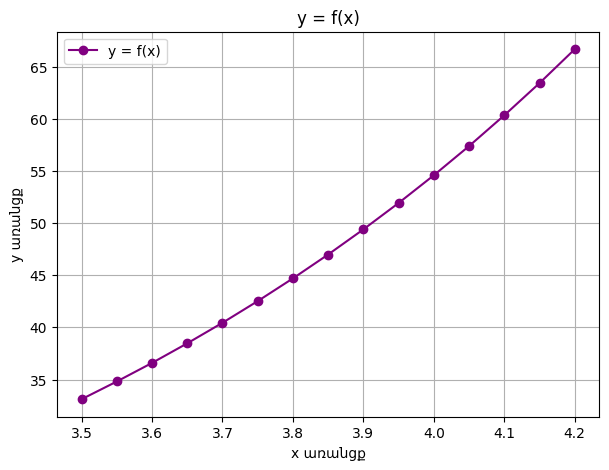

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(df["Xi"], df["fi"], marker='o', color='purple', label='y = f(x)')

plt.title("y = f(x)")
plt.xlabel("x առանցք")
plt.ylabel("y առանցք")
plt.grid(True)
plt.legend()

# plt.show()